# Siamese vs. Standard GIN Training: Graph Classification Comparison

Both schemes use the **same dataset, same graph architecture, same sort readout, and same classifier MLP**.
The only difference is how the GIN encoder is trained.

| | Siamese | Standard |
|---|---|---|
| **GIN training** | Triplet margin loss on permuted pairs, then frozen | Joint end-to-end with cross-entropy |
| **Inductive bias** | Alignment-oriented (equivariant matching) | Classification-oriented (discriminate pair types) |
| **Training steps** | 1 000 pretrain + 2 000 classifier | 2 000 joint |

**Dataset** follows `gin_depth_graph_classification`: N=1000 train pairs/class,
200 test pairs/class, 200 noisy-iso pairs per $k$ for the by-$k$ sweep.

## 0. Setup

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv
from torch_geometric.data import Data, Batch as PyGBatch
import numpy as np
import random
import warnings
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Graph / model hyperparameters (shared) ────────────────────────────────────
N_NODES    = 30
ER_PROB    = 0.3
FEAT_DIM   = 1
HIDDEN_DIM = 64
EMBED_DIM  = 32
GRAPH_DIM  = 64
N_CLASSES  = 3
DEPTH_VALUES = [2, 3, 4, 5]

# ── Siamese hyperparameters ───────────────────────────────────────────────────
GIN_MARGIN = 0.5
GIN_STEPS  = 1000
CLS_STEPS  = 2000

# ── Standard hyperparameters ──────────────────────────────────────────────────
STD_STEPS  = 2000

# ── Shared optimizer settings ─────────────────────────────────────────────────
BATCH_SIZE = 64
LR         = 1e-3
WD         = 1e-4

# ── Dataset (same as gin_depth_graph_classification) ─────────────────────────
N_TRAIN       = 1000
N_TEST        = 200
N_TEST_PER_K  = 200
NOISY_K_TRAIN = [1, 2, 3, 4]
NOISY_K_TEST  = [1, 2, 3, 4]

LABEL_ISO   = 0
LABEL_NOISY = 1
LABEL_IRR   = 2
CLASS_NAMES = ['Isomorphic', 'Noisy Iso', 'Irrelevant']

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 130})
CMAP_L  = cm.viridis
NORM_L  = plt.Normalize(vmin=min(DEPTH_VALUES), vmax=max(DEPTH_VALUES))
COLOR_L = {L: CMAP_L(NORM_L(L)) for L in DEPTH_VALUES}

SCHEME_STYLE = {
    'Siamese':  {'color': 'steelblue', 'ls': '-',  'marker': 's'},
    'Standard': {'color': 'tomato',    'ls': '--', 'marker': 'o'},
}

Device: cuda


## 1. Graph Generation

In [39]:
def sample_er_graph(n=N_NODES, p=ER_PROB, feat_dim=FEAT_DIM, seed=None):
    rng    = np.random.RandomState(seed) if seed is not None else np.random
    A      = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i + 1, n):
            if rng.rand() < p:
                A[i, j] = A[j, i] = 1.0
    degree     = (A.sum(1, keepdims=True) / n).astype(np.float32)
    rand_attrs = (rng.randn(n, feat_dim - 1) * 0.1).astype(np.float32)
    return A, np.concatenate([degree, rand_attrs], axis=1)


def permute_graph(A, feats, seed=None):
    rng  = np.random.RandomState(seed) if seed is not None else np.random
    perm = rng.permutation(A.shape[0])
    return A[np.ix_(perm, perm)], feats[perm].copy()


def perturb_graph(A, feats, k, seed=None):
    rng        = np.random.RandomState(seed) if seed is not None else np.random
    n          = A.shape[0]
    Ap         = A.copy()
    rows, cols = np.triu_indices(n, k=1)
    for idx in rng.choice(len(rows), min(k, len(rows)), replace=False):
        r, c = rows[idx], cols[idx]
        Ap[r, c] = Ap[c, r] = 1.0 - Ap[r, c]
    fp       = feats.copy()
    fp[:, 0] = Ap.sum(1) / n
    return Ap, fp


def to_pyg(A, feats, device=DEVICE):
    ei = torch.tensor(np.array(np.where(A > 0)), dtype=torch.long)
    x  = torch.tensor(feats, dtype=torch.float32)
    return Data(x=x, edge_index=ei, num_nodes=A.shape[0]).to(device)


def make_iso_pair(seed):
    A, f   = sample_er_graph(seed=seed)
    Ap, fp = permute_graph(A, f, seed=seed + 1)
    return A, f, Ap, fp

def make_noisy_pair(seed, k):
    A, f   = sample_er_graph(seed=seed)
    Ap, fp = perturb_graph(A, f, k, seed=seed + 1)
    return A, f, Ap, fp

def make_irr_pair(seed):
    A1, f1 = sample_er_graph(seed=seed)
    A2, f2 = sample_er_graph(seed=seed + 100000)
    return A1, f1, A2, f2


print(f'Graph: {N_NODES} nodes, ER p={ER_PROB}')

Graph: 30 nodes, ER p=0.3


## 2. Models

Both schemes share `GINEncoder` and `SortReadout`.
- **Siamese**: frozen `GINEncoder` + `GraphPairClassifier` (readout + MLP trained on pre-computed embeddings).
- **Standard**: `GINEndToEnd` wraps all three and trains jointly.

In [40]:
# ── Shared components ─────────────────────────────────────────────────────────
class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]
        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(dims[i], dims[i+1]), nn.ReLU(),
                nn.Linear(dims[i+1], dims[i+1]),
            )
            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(nn.BatchNorm1d(dims[i+1]))

    def forward(self, data):
        x, ei = data.x, data.edge_index
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, ei)))
        return F.normalize(x, p=2, dim=1)


class SortReadout(nn.Module):
    """Supports single-graph (n, d) and batched (B, n, d) inputs."""
    def __init__(self, n_nodes, in_dim, out_dim):
        super().__init__()
        self.rho = nn.Linear(in_dim, in_dim)
        self.a   = nn.Parameter(torch.ones(in_dim))
        self.b   = nn.Linear(n_nodes * in_dim, out_dim)

    def forward(self, x):
        h = self.rho(x) * self.a
        if x.dim() == 2:                        # single graph (n, d)
            h, _ = torch.sort(h, dim=0)
            return self.b(h.flatten().unsqueeze(0)).squeeze(0)
        else:                                   # batched (B, n, d)
            h, _ = torch.sort(h, dim=1)
            return self.b(h.flatten(start_dim=1))


def _make_mlp():
    return nn.Sequential(
        nn.Linear(2 * GRAPH_DIM, GRAPH_DIM), nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(GRAPH_DIM, GRAPH_DIM // 2), nn.ReLU(),
        nn.Linear(GRAPH_DIM // 2, N_CLASSES),
    )


# ── Siamese: readout + classifier on top of frozen GIN ────────────────────────
class GraphPairClassifier(nn.Module):
    """Takes pre-computed node embeddings (frozen GIN output)."""
    def __init__(self):
        super().__init__()
        self.readout = SortReadout(N_NODES, EMBED_DIM, GRAPH_DIM)
        self.mlp     = _make_mlp()

    def forward(self, emb1, emb2):              # single pair: (n, d)
        g1   = self.readout(emb1)
        g2   = self.readout(emb2)
        feat = torch.cat([torch.abs(g1 - g2), g1 * g2])
        return self.mlp(feat.unsqueeze(0)).squeeze(0)

    def forward_batch(self, emb1, emb2):        # batched: (B, n, d)
        g1   = self.readout(emb1)               # (B, graph_dim)
        g2   = self.readout(emb2)
        feat = torch.cat([torch.abs(g1 - g2), g1 * g2], dim=1)
        return self.mlp(feat)                   # (B, N_CLASSES)


# ── Standard: encoder + readout + classifier trained jointly ──────────────────
class GINEndToEnd(nn.Module):
    def __init__(self, num_layers):
        super().__init__()
        self.encoder = GINEncoder(FEAT_DIM, HIDDEN_DIM, EMBED_DIM, num_layers)
        self.readout = SortReadout(N_NODES, EMBED_DIM, GRAPH_DIM)
        self.mlp     = _make_mlp()

    def forward(self, data1, data2):            # single-pair (for eval)
        g1   = self.readout(self.encoder(data1))
        g2   = self.readout(self.encoder(data2))
        feat = torch.cat([torch.abs(g1 - g2), g1 * g2])
        return self.mlp(feat.unsqueeze(0)).squeeze(0)

    def forward_batch(self, batch1, batch2, B): # batched (for training)
        emb1 = self.encoder(batch1).view(B, N_NODES, EMBED_DIM)
        emb2 = self.encoder(batch2).view(B, N_NODES, EMBED_DIM)
        feat = torch.cat([torch.abs(self.readout(emb1) - self.readout(emb2)),
                          self.readout(emb1) * self.readout(emb2)], dim=1)
        return self.mlp(feat)


# ── Utilities ─────────────────────────────────────────────────────────────────
def compute_margin(emb):
    with torch.no_grad():
        d    = torch.cdist(emb, emb, p=2)
        mask = ~torch.eye(d.shape[0], dtype=torch.bool, device=d.device)
        return d[mask].min().item()


def triplet_margin_loss(emb_A, emb_Ap, margin):
    n       = emb_A.shape[0]
    d_pos   = (emb_A - emb_Ap).norm(p=2, dim=1)
    shift   = torch.randint(1, n, (n,), device=emb_A.device)
    neg_idx = (torch.arange(n, device=emb_A.device) + shift) % n
    d_neg   = (emb_A - emb_A[neg_idx]).norm(p=2, dim=1)
    return F.relu(d_pos - d_neg + margin).mean()


def measure_gamma(encoder, n_graphs=50):
    g_list = []
    with torch.no_grad():
        for s in range(n_graphs):
            A_t, f_t = sample_er_graph(seed=s + 9000)
            g_list.append(compute_margin(encoder(to_pyg(A_t, f_t))))
    return float(np.mean(g_list))


print('All model classes defined.')

All model classes defined.


## 3. Dataset

Raw graph pairs are built once with fixed seeds (matching `gin_depth_graph_classification`).
- **Standard** uses raw PyG pairs directly.
- **Siamese** calls `precompute_dataset` with the frozen GIN after pretraining (per depth).

In [41]:
def build_raw_dataset(n_per_class, k_range, seed_offset=0):
    data = []
    for i in range(n_per_class):
        s = seed_offset + i
        A1, f1, A2, f2 = make_iso_pair(s * 3)
        data.append((A1, f1, A2, f2, LABEL_ISO, 0))
        k = k_range[i % len(k_range)]
        A1, f1, A2, f2 = make_noisy_pair(s * 3 + 1, k)
        data.append((A1, f1, A2, f2, LABEL_NOISY, k))
        A1, f1, A2, f2 = make_irr_pair(s * 3 + 2)
        data.append((A1, f1, A2, f2, LABEL_IRR, 0))
    return data


def build_raw_by_k(n_per_k, k_values, seed_offset=500000):
    by_k = defaultdict(list)
    for k in k_values:
        for i in range(n_per_k):
            s = seed_offset + k * 10000 + i
            A1, f1, A2, f2 = make_noisy_pair(s, k)
            by_k[k].append((A1, f1, A2, f2, LABEL_NOISY, k))
    return by_k


def to_pyg_pairs(raw):
    """Pre-convert raw numpy pairs to PyG on CPU."""
    return [(to_pyg(A1, f1).cpu(), to_pyg(A2, f2).cpu(), lbl, k)
            for A1, f1, A2, f2, lbl, k in raw]


@torch.no_grad()
def embed_dataset(gin, raw):
    """Siamese: embed raw pairs with frozen GIN, store on CPU."""
    return [(gin(to_pyg(A1, f1)).cpu(), gin(to_pyg(A2, f2)).cpu(), lbl, k)
            for A1, f1, A2, f2, lbl, k in raw]


print('Building raw datasets (fixed seeds, shared across both schemes)...')
raw_train = build_raw_dataset(N_TRAIN, NOISY_K_TRAIN, seed_offset=0)
raw_test  = build_raw_dataset(N_TEST,  NOISY_K_TEST,  seed_offset=200000)
raw_by_k  = build_raw_by_k(N_TEST_PER_K, NOISY_K_TEST, seed_offset=500000)

# Standard pre-converts to PyG once
pyg_train = to_pyg_pairs(raw_train)
pyg_test  = to_pyg_pairs(raw_test)
pyg_by_k  = {k: to_pyg_pairs(v) for k, v in raw_by_k.items()}

print(f'Train: {len(raw_train)} pairs  |  Test: {len(raw_test)} pairs')
print(f'By-k:  {N_TEST_PER_K} noisy pairs per k={NOISY_K_TEST}')

Building raw datasets (fixed seeds, shared across both schemes)...
Train: 3000 pairs  |  Test: 600 pairs
By-k:  200 noisy pairs per k=[1, 2, 3, 4]


## 4. Training — Both Schemes, All Depths

In [42]:
# ── Siamese training ──────────────────────────────────────────────────────────
def train_gin_siamese(num_layers, seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    model = GINEncoder(FEAT_DIM, HIDDEN_DIM, EMBED_DIM, num_layers).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=5e-4)
    for _ in range(GIN_STEPS):
        model.train()
        A, f   = sample_er_graph()
        Ap, fp = permute_graph(A, f)
        loss   = triplet_margin_loss(
            model(to_pyg(A, f)), model(to_pyg(Ap, fp)), GIN_MARGIN)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model


def train_classifier(emb_train, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    clf   = GraphPairClassifier().to(DEVICE)
    opt   = torch.optim.Adam(clf.parameters(), lr=LR, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CLS_STEPS)

    # Pre-stack all embeddings on GPU once — avoids 64 × .to(DEVICE) per step
    # Memory: 3000 pairs × 2 × (30 × 32) floats ≈ 23 MB, trivial on any GPU
    embs1  = torch.stack([e[0] for e in emb_train]).to(DEVICE)  # (N, n, d)
    embs2  = torch.stack([e[1] for e in emb_train]).to(DEVICE)
    labels = torch.tensor([e[2] for e in emb_train],
                          dtype=torch.long, device=DEVICE)
    n      = len(emb_train)
    losses = []

    for _ in range(CLS_STEPS):
        clf.train()
        idx    = torch.randint(n, (BATCH_SIZE,), device=DEVICE)
        logits = clf.forward_batch(embs1[idx], embs2[idx])
        loss   = F.cross_entropy(logits, labels[idx])
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(clf.parameters(), 1.0)
        opt.step(); sched.step()
        losses.append(loss.item())

    clf.eval()
    return clf, losses


# ── Standard training ─────────────────────────────────────────────────────────
def train_standard(num_layers, train_data, seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    model  = GINEndToEnd(num_layers).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=STD_STEPS)
    n      = len(train_data)
    losses = []
    for _ in range(STD_STEPS):
        model.train()
        idx   = np.random.choice(n, BATCH_SIZE, replace=True)
        items = [train_data[i] for i in idx]
        b1    = PyGBatch.from_data_list([it[0] for it in items]).to(DEVICE)
        b2    = PyGBatch.from_data_list([it[1] for it in items]).to(DEVICE)
        lbls  = torch.tensor([it[2] for it in items],
                             dtype=torch.long, device=DEVICE)
        loss  = F.cross_entropy(model.forward_batch(b1, b2, len(idx)), lbls)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        losses.append(loss.item())
    model.eval()
    return model, losses


print('Training functions defined.')

Training functions defined.


In [43]:
siamese_models  = {}   # {L: (gin, clf)}
standard_models = {}   # {L: model}
siamese_gammas  = {}
standard_gammas = {}
siamese_losses  = {}
standard_losses = {}

for L in DEPTH_VALUES:
    print(f'\n── L={L} ──────────────────────────────────────────')

    # Siamese
    print(f'  [Siamese] GIN pretraining ({GIN_STEPS} steps) ...', end=' ', flush=True)
    gin = train_gin_siamese(L)
    siamese_gammas[L] = measure_gamma(gin)
    print(f'done  γ={siamese_gammas[L]:.4f}')

    print(f'  [Siamese] Embedding dataset + training classifier ({CLS_STEPS} steps) ...',
          end=' ', flush=True)
    emb_train = embed_dataset(gin, raw_train)
    clf, s_hist = train_classifier(emb_train)
    siamese_models[L]  = (gin, clf)
    siamese_losses[L]  = s_hist
    print(f'done  loss={np.mean(s_hist[-200:]):.4f}')

    # Standard
    print(f'  [Standard] End-to-end training ({STD_STEPS} steps) ...',
          end=' ', flush=True)
    std_model, std_hist = train_standard(L, pyg_train)
    standard_models[L] = std_model
    standard_losses[L] = std_hist
    standard_gammas[L] = measure_gamma(std_model.encoder)
    print(f'done  loss={np.mean(std_hist[-200:]):.4f}  γ={standard_gammas[L]:.4f}')

print('\nAll models trained.')


── L=2 ──────────────────────────────────────────
  [Siamese] GIN pretraining (1000 steps) ... done  γ=0.0527
  [Siamese] Embedding dataset + training classifier (2000 steps) ... done  loss=0.0340
  [Standard] End-to-end training (2000 steps) ... done  loss=0.2415  γ=0.0905

── L=3 ──────────────────────────────────────────
  [Siamese] GIN pretraining (1000 steps) ... done  γ=0.0614
  [Siamese] Embedding dataset + training classifier (2000 steps) ... done  loss=0.1039
  [Standard] End-to-end training (2000 steps) ... done  loss=0.2937  γ=0.0962

── L=4 ──────────────────────────────────────────
  [Siamese] GIN pretraining (1000 steps) ... done  γ=0.0255
  [Siamese] Embedding dataset + training classifier (2000 steps) ... done  loss=0.1380
  [Standard] End-to-end training (2000 steps) ... done  loss=0.3827  γ=0.0535

── L=5 ──────────────────────────────────────────
  [Siamese] GIN pretraining (1000 steps) ... done  γ=0.0087
  [Siamese] Embedding dataset + training classifier (2000 ste

## 5. Evaluation

In [44]:
@torch.no_grad()
def evaluate_siamese(gin, clf, pyg_data):
    gin.eval(); clf.eval()
    preds, labels = [], []
    for d1, d2, lbl, _ in pyg_data:
        e1 = gin(d1.to(DEVICE))
        e2 = gin(d2.to(DEVICE))
        preds.append(clf(e1, e2).argmax().item())
        labels.append(lbl)
    preds, labels = np.array(preds), np.array(labels)
    acc       = (preds == labels).mean()
    per_class = {c: float((preds[labels == c] == c).mean()) for c in range(N_CLASSES)}
    return acc, per_class, preds, labels


@torch.no_grad()
def evaluate_standard(model, pyg_data):
    model.eval()
    preds, labels = [], []
    for d1, d2, lbl, _ in pyg_data:
        preds.append(model(d1.to(DEVICE), d2.to(DEVICE)).argmax().item())
        labels.append(lbl)
    preds, labels = np.array(preds), np.array(labels)
    acc       = (preds == labels).mean()
    per_class = {c: float((preds[labels == c] == c).mean()) for c in range(N_CLASSES)}
    return acc, per_class, preds, labels


@torch.no_grad()
def eval_by_k_siamese(gin, clf, by_k):
    gin.eval(); clf.eval()
    return {
        k: sum(clf(gin(d1.to(DEVICE)), gin(d2.to(DEVICE))).argmax().item() == LABEL_NOISY
               for d1, d2, _, __ in data) / len(data)
        for k, data in by_k.items()
    }


@torch.no_grad()
def eval_by_k_standard(model, by_k):
    model.eval()
    return {
        k: sum(model(d1.to(DEVICE), d2.to(DEVICE)).argmax().item() == LABEL_NOISY
               for d1, d2, _, __ in data) / len(data)
        for k, data in by_k.items()
    }


print('Evaluating both schemes on shared test set...')
results = {'Siamese': {}, 'Standard': {}}

for L in DEPTH_VALUES:
    gin, clf  = siamese_models[L]
    std_model = standard_models[L]

    s_acc, s_pc, s_pred, s_lbl = evaluate_siamese(gin, clf, pyg_test)
    t_acc, t_pc, t_pred, t_lbl = evaluate_standard(std_model, pyg_test)

    results['Siamese'][L]  = {'acc': s_acc, 'per_class': s_pc,
                               'preds': s_pred, 'labels': s_lbl,
                               'acc_vs_k': eval_by_k_siamese(gin, clf, pyg_by_k),
                               'gamma': siamese_gammas[L]}
    results['Standard'][L] = {'acc': t_acc, 'per_class': t_pc,
                               'preds': t_pred, 'labels': t_lbl,
                               'acc_vs_k': eval_by_k_standard(std_model, pyg_by_k),
                               'gamma': standard_gammas[L]}

    print(f'  L={L}  Siamese: acc={s_acc:.3f} γ={siamese_gammas[L]:.4f}  '
          f'| Standard: acc={t_acc:.3f} γ={standard_gammas[L]:.4f}')

Evaluating both schemes on shared test set...
  L=2  Siamese: acc=0.975 γ=0.0527  | Standard: acc=0.887 γ=0.0905
  L=3  Siamese: acc=0.957 γ=0.0614  | Standard: acc=0.903 γ=0.0962
  L=4  Siamese: acc=0.938 γ=0.0255  | Standard: acc=0.855 γ=0.0535
  L=5  Siamese: acc=0.933 γ=0.0087  | Standard: acc=0.800 γ=0.0172


## 6. Comparison Figures

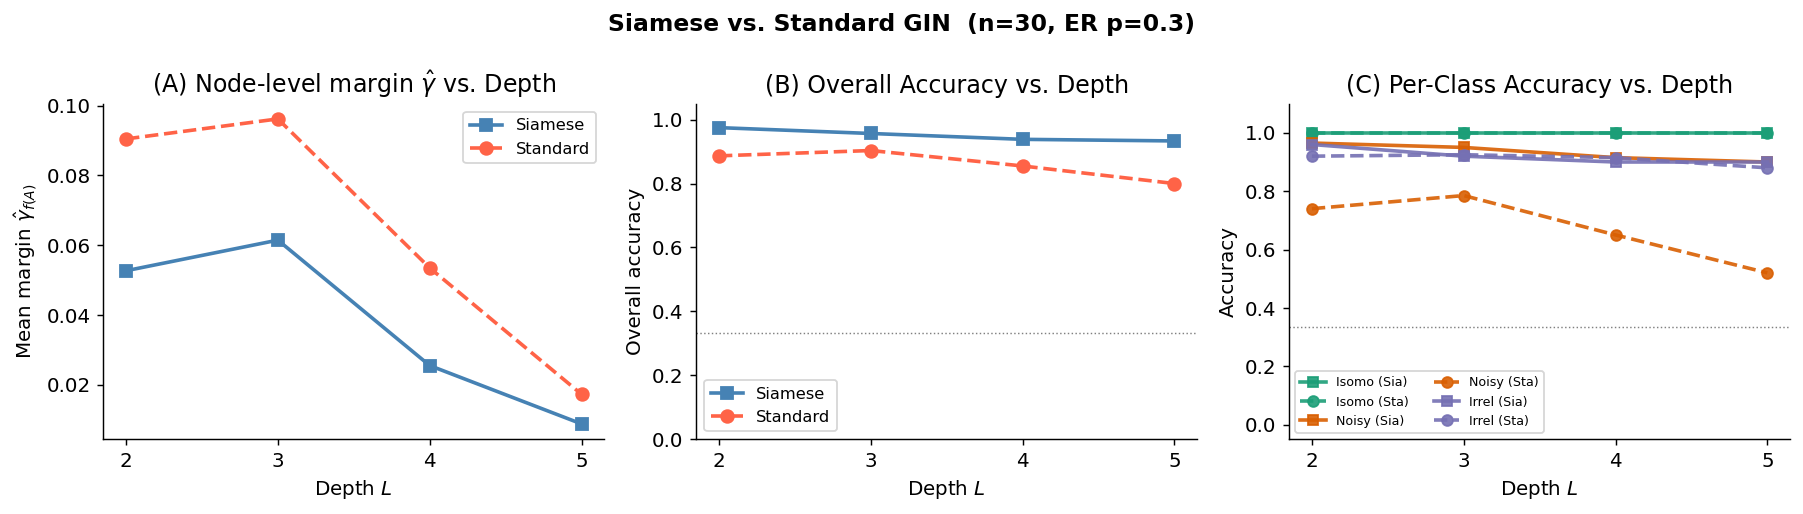

In [45]:
Ls      = DEPTH_VALUES
schemes = ['Siamese', 'Standard']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    f'Siamese vs. Standard GIN  (n={N_NODES}, ER p={ER_PROB})',
    fontsize=13, fontweight='bold'
)

# ── (A) γ vs depth ────────────────────────────────────────────────────────────
ax = axes[0]
for scheme in schemes:
    st = SCHEME_STYLE[scheme]
    ax.plot(Ls, [results[scheme][L]['gamma'] for L in Ls],
            marker=st['marker'], ls=st['ls'], color=st['color'],
            linewidth=2, markersize=7, label=scheme)
ax.set_xlabel('Depth $L$'); ax.set_ylabel('Mean margin $\\hat{\\gamma}_{f(A)}$')
ax.set_title('(A) Node-level margin $\\hat{\\gamma}$ vs. Depth')
ax.set_xticks(Ls); ax.legend(fontsize=9)

# ── (B) Overall accuracy vs depth ────────────────────────────────────────────
ax = axes[1]
for scheme in schemes:
    st = SCHEME_STYLE[scheme]
    ax.plot(Ls, [results[scheme][L]['acc'] for L in Ls],
            marker=st['marker'], ls=st['ls'], color=st['color'],
            linewidth=2, markersize=7, label=scheme)
ax.axhline(1/3, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('Depth $L$'); ax.set_ylabel('Overall accuracy')
ax.set_title('(B) Overall Accuracy vs. Depth')
ax.set_xticks(Ls); ax.set_ylim(0, 1.05); ax.legend(fontsize=9)

# ── (C) Per-class accuracy vs depth ──────────────────────────────────────────
ax   = axes[2]
cls_colors = ['#1b9e77', '#d95f02', '#7570b3']
for c, (cname, ccol) in enumerate(zip(CLASS_NAMES, cls_colors)):
    for scheme in schemes:
        st = SCHEME_STYLE[scheme]
        vals = [results[scheme][L]['per_class'][c] for L in Ls]
        ax.plot(Ls, vals, marker=st['marker'], ls=st['ls'], color=ccol,
                linewidth=2, markersize=6, alpha=0.9,
                label=f'{cname[:5]} ({scheme[:3]})')
ax.axhline(1/3, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('Depth $L$'); ax.set_ylabel('Accuracy')
ax.set_title('(C) Per-Class Accuracy vs. Depth')
ax.set_xticks(Ls); ax.set_ylim(-0.05, 1.1); ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('comparison_acc_gamma_vs_depth.pdf', bbox_inches='tight')
plt.savefig('comparison_acc_gamma_vs_depth.png', bbox_inches='tight', dpi=150)
plt.show()

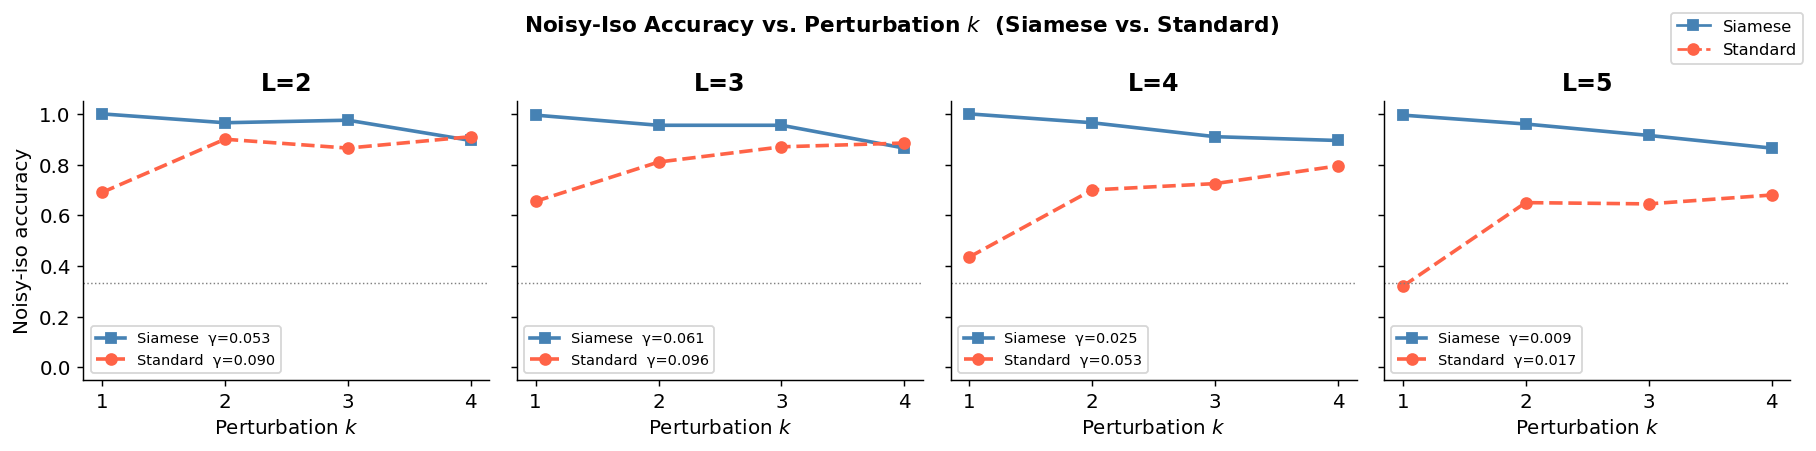

In [46]:
# ── Noisy-iso accuracy vs k, one subplot per depth ────────────────────────────
fig, axes = plt.subplots(1, len(DEPTH_VALUES), figsize=(14, 3.5), sharey=True)
fig.suptitle(
    'Noisy-Iso Accuracy vs. Perturbation $k$  (Siamese vs. Standard)',
    fontsize=12, fontweight='bold'
)

k_vals = sorted(pyg_by_k.keys())
for ax, L in zip(axes, DEPTH_VALUES):
    for scheme in schemes:
        st  = SCHEME_STYLE[scheme]
        ak  = results[scheme][L]['acc_vs_k']
        ax.plot(k_vals, [ak[k] for k in k_vals],
                marker=st['marker'], ls=st['ls'], color=st['color'],
                linewidth=2, markersize=6,
                label=f"{scheme}  γ={results[scheme][L]['gamma']:.3f}")
    ax.axhline(1/3, color='grey', linestyle=':', linewidth=0.8)
    ax.set_title(f'L={L}', fontweight='bold')
    ax.set_xlabel('Perturbation $k$')
    ax.set_xticks(k_vals)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Noisy-iso accuracy')

# Shared legend
h1 = mlines.Line2D([], [], color=SCHEME_STYLE['Siamese']['color'],
                   ls='-', marker='s', label='Siamese')
h2 = mlines.Line2D([], [], color=SCHEME_STYLE['Standard']['color'],
                   ls='--', marker='o', label='Standard')
fig.legend(handles=[h1, h2], loc='upper right', fontsize=9,
           bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.savefig('comparison_noisy_acc_vs_k.pdf', bbox_inches='tight')
plt.savefig('comparison_noisy_acc_vs_k.png', bbox_inches='tight', dpi=150)
plt.show()

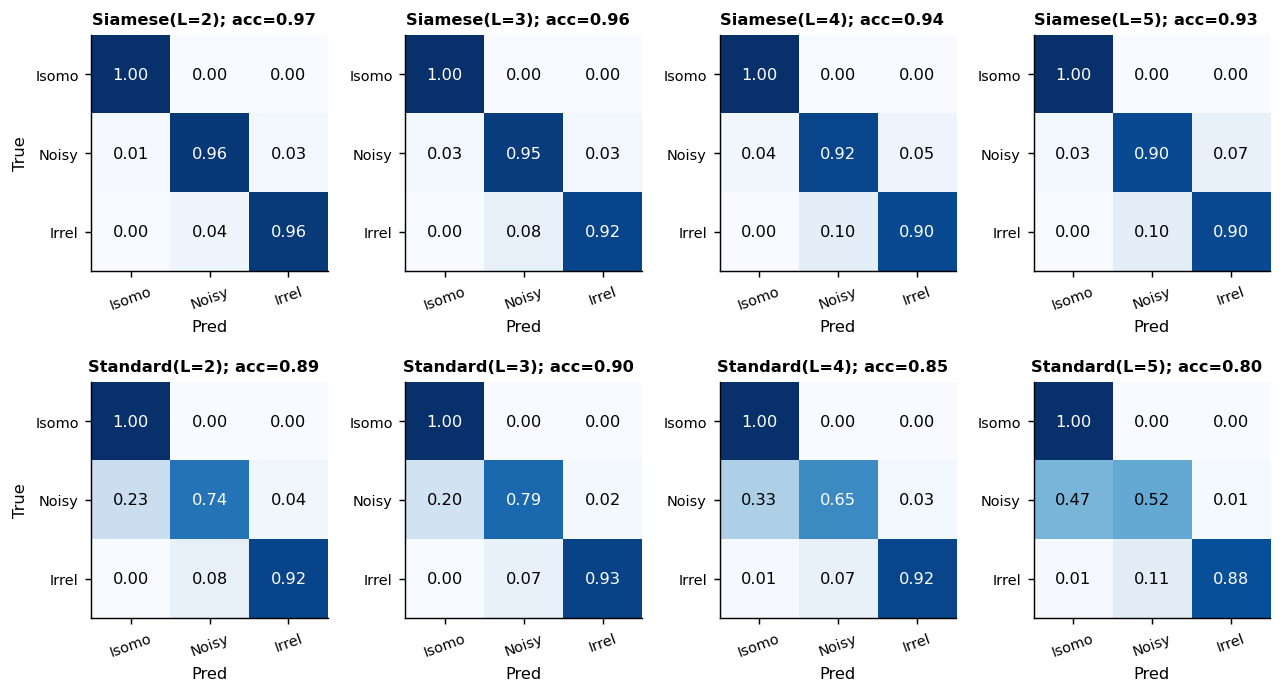

In [62]:
# ── Confusion matrices: 2 rows (schemes) × 4 cols (depths) ───────────────────
fig, axes = plt.subplots(2, len(DEPTH_VALUES), figsize=(10, 5.5))
# fig.suptitle('Confusion Matrices  (rows = Siamese v.s. Standard, cols = L)',
#              fontsize=12, fontweight='bold')
short = [n[:5] for n in CLASS_NAMES]

for row, scheme in enumerate(schemes):
    for col, L in enumerate(DEPTH_VALUES):
        ax    = axes[row][col]
        preds = results[scheme][L]['preds']
        lbls  = results[scheme][L]['labels']
        cm_arr = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
        for p, l in zip(preds, lbls): cm_arr[l, p] += 1
        cm_norm = cm_arr.astype(float) / cm_arr.sum(1, keepdims=True).clip(min=1)
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
        ax.set_xticklabels(short, rotation=20, fontsize=8)
        ax.set_yticklabels(short, fontsize=8)
        for r in range(N_CLASSES):
            for c in range(N_CLASSES):
                ax.text(c, r, f'{cm_norm[r,c]:.2f}', ha='center', va='center',
                        fontsize=9, color='white' if cm_norm[r,c] > 0.55 else 'black')
        ax.set_title(f'{scheme}(L={L}); acc={results[scheme][L]["acc"]:.2f}  ',fontsize=9, fontweight='bold')
        if col == 0: ax.set_ylabel('True', fontsize=9)
        ax.set_xlabel('Pred', fontsize=9)

plt.tight_layout()
plt.savefig('comparison_confusion.pdf', bbox_inches='tight')
plt.savefig('comparison_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Summary Table

In [48]:
hdr = (f"{'Scheme':<10} {'L':>2}  {'γ':>8}  {'Overall':>8}  "
       f"{'Iso':>7}  {'Noisy':>7}  {'Irr':>7}  "
       + '  '.join(f'k={k}' for k in sorted(pyg_by_k.keys())))
print(hdr); print('─' * len(hdr))

for scheme in schemes:
    for L in DEPTH_VALUES:
        r  = results[scheme][L]
        ak = r['acc_vs_k']
        kstr = '  '.join(f'{ak[k]:>5.3f}' for k in sorted(ak.keys()))
        print(f"{scheme:<10} {L:>2}  {r['gamma']:>8.4f}  {r['acc']:>8.3f}  "
              f"{r['per_class'][0]:>7.3f}  {r['per_class'][1]:>7.3f}  "
              f"{r['per_class'][2]:>7.3f}  {kstr}")
    print()

Scheme      L         γ   Overall      Iso    Noisy      Irr  k=1  k=2  k=3  k=4
────────────────────────────────────────────────────────────────────────────────
Siamese     2    0.0527     0.975    1.000    0.965    0.960  1.000  0.965  0.975  0.895
Siamese     3    0.0614     0.957    1.000    0.950    0.920  0.995  0.955  0.955  0.865
Siamese     4    0.0255     0.938    1.000    0.915    0.900  1.000  0.965  0.910  0.895
Siamese     5    0.0087     0.933    1.000    0.900    0.900  0.995  0.960  0.915  0.865

Standard    2    0.0905     0.887    1.000    0.740    0.920  0.690  0.900  0.865  0.910
Standard    3    0.0962     0.903    1.000    0.785    0.925  0.655  0.810  0.870  0.885
Standard    4    0.0535     0.855    1.000    0.650    0.915  0.435  0.700  0.725  0.795
Standard    5    0.0172     0.800    1.000    0.520    0.880  0.320  0.650  0.645  0.680

